# **Telco Customer Churn Analysis**

# Table of Contents

1. Introduction
2. Dataset Description
3. Data Cleaning
4. Exploratory Data Analysis
5. Statistical Validation
6. Predictive Modeling
7. Feature Importance
8. Business Recommendations
9. Conclusion

#1. Introduction

##Objective

Customer churn directly impacts company revenue and growth. The objective of this project is to analyze customer behavior, identify major churn drivers, and build a predictive model to detect customers at risk of leaving.

##Business Problem

A telecom company wants to understand:

* Why customers leave
* Which customers are at high risk
* What actions can reduce churn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix,roc_curve,auc
from sklearn.ensemble import RandomForestClassifier


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Telco_customer_churn.xlsx to Telco_customer_churn (3).xlsx


In [ ]:
df = pd.read_excel("Telco_customer_churn.xlsx")

-------------------------------------

# 2. Dataset Description and Understanding

In [ ]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [ ]:
df.shape

(7043, 33)

## Dataset:
* 7043 customer records
* 33 variables

In [ ]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [ ]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Total Charges"].apply(type).value_counts()

,count
Total Charges,
<class 'float'>,6708
<class 'int'>,324
<class 'str'>,11


## Activities Performed
* Examined dataset dimensions
* Reviewed data types
* Checked missing values
* Investigated duplicate records
* Understood business meaning of columns

## Observations
* No duplicate customer records found.
* Churn Reason contained missing values because non-churn customers do not have churn reasons.
* Total Charges required datatype correction

-------------------------

#3. Data Cleaning & Preparation

In [ ]:
df["Churn Reason"] = df["Churn Reason"].fillna("No Churn!")

 Missing values in Churn Reason represent customers who did not churn and were preserved for interpretation.

In [ ]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

In [ ]:
df["Total Charges"].isnull().sum()

np.int64(11)

In [ ]:
df[df["Total Charges"].isnull()][
[
"CustomerID",
"Tenure Months",
"Monthly Charges",
"Churn Label"
]
]

,CustomerID,Tenure Months,Monthly Charges,Churn Label
2234,4472-LVYGI,0,52.55,No
2438,3115-CZMZD,0,20.25,No
2568,5709-LVOEQ,0,80.85,No
2667,4367-NUYAO,0,25.75,No
2856,1371-DWPAZ,0,56.05,No
4331,7644-OMVMY,0,19.85,No
4687,3213-VVOLG,0,25.35,No
5104,2520-SGTTA,0,20.00,No
5719,2923-ARZLG,0,19.70,No
6772,4075-WKNIU,0,73.35,No


In [ ]:
df["Total Charges"] = df["Total Charges"].fillna(0)

Because some rows likely had blank spaces in Total Charges.

A customer may have
joined recently has tenure = 0.
Therefore no accumulated charges

In [ ]:
df["Total Charges"].isnull().sum()

np.int64(0)

## Cleaning Steps
* Converted Total Charges to numeric format.
* Handled missing values using business logic (churn value).
* Replaced missing Total Charges with 0 for customers with zero tenure.


---------------

#4. Exploratory Data Analysis (EDA)

##4.1 Overall Churn Distribution

In [ ]:
churn = (df["Churn Label"].value_counts(normalize=True)*100)

In [ ]:
print(churn)

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


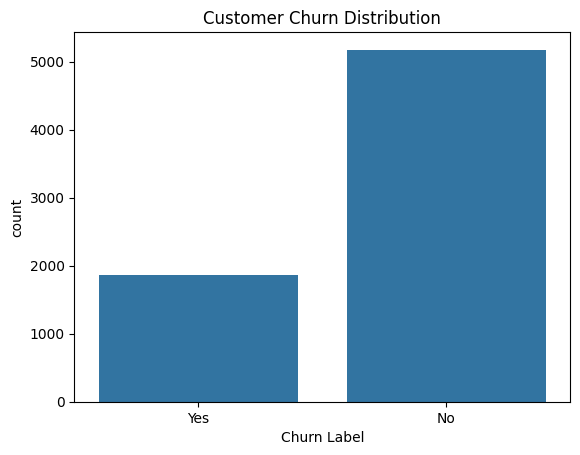

In [ ]:
sns.countplot(x="Churn Label", data=df)
plt.title("Customer Churn Distribution")
plt.show()

##Insight 1
* Churn Rate = 26.54%
* Approximately 1 in 4 customers left.

### This is not catastrophic, but it is high enough to affect revenue and customer acquisition costs, retention should become a business priority.

##4.2 Contract Type Analysis

In [ ]:
contract_churn = (pd.crosstab(
    df["Contract"],
    df["Churn Label"],
    normalize="index")*100)
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


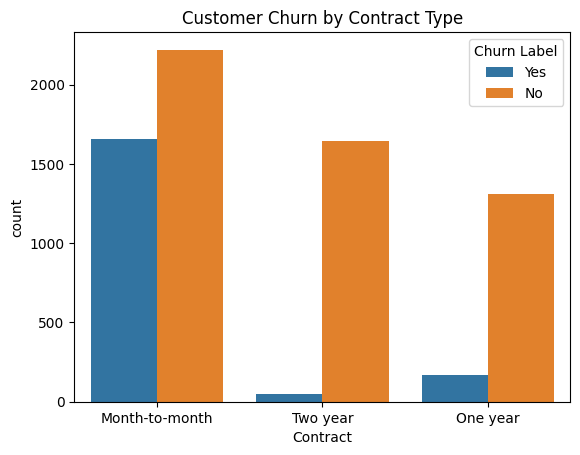

In [ ]:
sns.countplot(x="Contract",hue="Churn Label",data=df)
plt.title("Customer Churn by Contract Type")
plt.show()

## Insight 2
* Month-to-month customers showed the highest churn (42.7%).
* Two-year contracts showed lowest churn (2.8%).
* Longer commitment appears strongly associated with customer retention.

###  Encourage month-to-month customers to move into annual plans.

* Offer renewal discounts.
* Create retention campaigns before month 6–12.

# 4.3 Customer Tenure Analysis

In [ ]:
df.groupby("Churn Label")["Tenure Months"].mean()

,Tenure Months
Churn Label,
No,37.569965
Yes,17.979133


## Insight 3
* Churned customers had average tenure of 18 months.
* Retained customers averaged 38 months.
* First year experience matters a lot.
* Onboarding, support, and service quality may influence retention.

### Customer retention risk is highest during the early customer lifecycle.

##4.4 Monthly Charges Analysis

In [ ]:
df.groupby("Churn Label")["Monthly Charges"].mean()

,Monthly Charges
Churn Label,
No,61.265124
Yes,74.441332


## Insight 4
* Churned customers paid higher monthly charges.

# 4.5 Internet Service Analysis

In [ ]:
pd.crosstab(
    df["Internet Service"],
    df["Churn Label"],
    normalize="index")*100

Churn Label,No,Yes
Internet Service,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


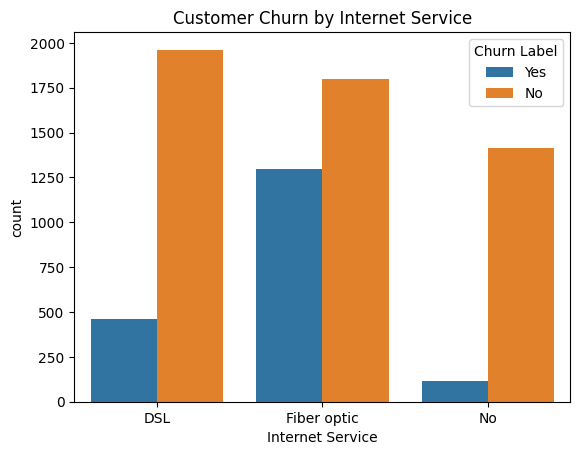

In [ ]:
sns.countplot(x="Internet Service", hue="Churn Label", data=df)
plt.title("Customer Churn by Internet Service")
plt.show()

# Insight 5
* Fiber optic customers showed highest churn (41.9%).
* Fiber optic customers are associated with significantly higher churn and should be investigated further.

## Since fiber is usually a premium service, this could indicate:
* pricing dissatisfaction
* service quality issues
* competitor pressure
* unmet expectations

# 4.6 Service Adoption Analysis

In [ ]:
pd.crosstab(
df["Online Security"],
df["Churn Label"],
normalize="index"
)*100

Churn Label,No,Yes
Online Security,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194



Customers without security service churn nearly 3× more.

* Bundle security with plans
* Offer free trials

In [ ]:
pd.crosstab(
df["Tech Support"],
df["Churn Label"],
normalize="index"
)*100

Churn Label,No,Yes
Tech Support,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


Customers with technical support remain substantially longer.

Support may act as a retention mechanism, not only a service expense.


## Insight 6

Customers with:

* Online Security
* Tech Support

showed significantly lower churn.

# 4.7 Payment Method Analysis

In [ ]:
pd.crosstab(
df["Payment Method"],
df["Churn Label"],
normalize="index"
)*100

Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


# Insight 7

* Electronic check users showed highest churn (45.3%).

Electronic check customers churn almost 3× more than automatic payment users.

Possible explanations:


* Lower engagement
* Less convenience
* Short-term customer behavior

## Migration towards auto-payment should be encouraged.


Now, we have something meaningul to conclude

# High-Risk Customer Profile
* Month-to-month contract
* Short tenure
* High monthly charges
* Fiber internet
* No online security
* No tech support
* Payment method

-------------------------------

# 5. Statistical Validation

## Chi-Square Test
* H₀:
  Contract type and churn are independent.

* H₁:
  Contract type and churn are associated.

In [ ]:
table = pd.crosstab(
    df["Contract"],
    df["Churn Label"]
)

chi2,p,dof,expected = chi2_contingency(table)


## Chi-Square Statistic (chi2)
* Measures how different the observed values are from the expected values. Higher value : stronger evidence that variables are related.


## P-value (p)
* Tells whether the relationship found is statistically significant or may have happened by chance.

## Degrees of Freedom (dof)
* Number of independent values used in the calculation.

* Formula:(rows − 1) × (columns − 1).

Basically a map to let the code knows it can't go beyond it, every event would occur inside it.

## Expected Frequencies (expected)
* The values we would expect if there were no relationship between the variables (null hypothesis is true).

In [ ]:
print("p-value:",p)

p-value: 5.863038300673391e-258


# P-value	Decision
* p < 0.05	Reject Null Hypothesis → Significant relationship exists
* p ≥ 0.05	Fail to Reject Null Hypothesis → No significant relationship

## Conclusion

Contract type showed statistically significant association with churn.

The Chi-Square test was performed to determine whether an association exists between the selected categorical variables. The obtained p-value (5.863e−258) is significantly lower than 0.05, indicating strong statistical evidence against the null hypothesis. Therefore, it can be concluded that a significant relationship exists between the variables.

-------------------------------

#6. Predictive Modeling

In [ ]:
drop_cols = [
"CustomerID",
"Count",
"Country",
"State",
"City",
"Zip Code",
"Lat Long",
"Latitude",
"Longitude",
"Churn Label",
"Churn Score",
"Churn Reason"
]

model_df = df.drop(columns=drop_cols)

In [ ]:
model_df = pd.get_dummies(
model_df,
drop_first=True
)

In [ ]:
model_df.shape

(7043, 32)

In [ ]:
X = model_df.drop(
    "Churn Value",
    axis=1)

y = model_df["Churn Value"]

X_train,X_test,y_train,y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y))

## Model 1 — Logistic Regression

In [ ]:
model = LogisticRegression(
    max_iter=5000
)

model.fit(
    X_train,
    y_train
)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=5000)

In [ ]:
pred = model.predict(X_test)

In [ ]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.58      0.61       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



The model demonstrated strong capability in identifying customers likely to churn while remaining interpretable.

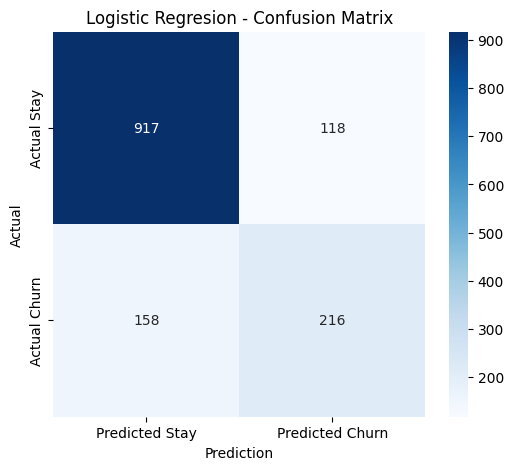

In [ ]:
cm = confusion_matrix(y_test,pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Stay","Predicted Churn"],
    yticklabels=["Actual Stay", "Actual Churn"]
)

plt.title("Logistic Regresion - Confusion Matrix")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.show()

* True Negatives (917)

These customers stayed and the model correctly predicted they would stay.


* True Positives (216)

These customers churned and the model successfully detected them.

This is valuable because these are customers the business could target.

* False Positives (118)

Model predicted churn but customer actually stayed.

Some retention offers may be wasted.

* False Negatives (158)

These are important.
Customer churned but model predicted stay.

Company misses opportunity to intervene.

## ROC Curve
After evaluating the model using accuracy, precision, recall, and F1-score, the ROC Curve is used to measure how well the model distinguishes between churn and non-churn customers across different classification thresholds.

The ROC curve provides a visual representation of model performance, while the AUC (Area Under Curve) score summarizes the model’s ability to correctly separate the two classes.

A higher AUC value indicates better classification performance.


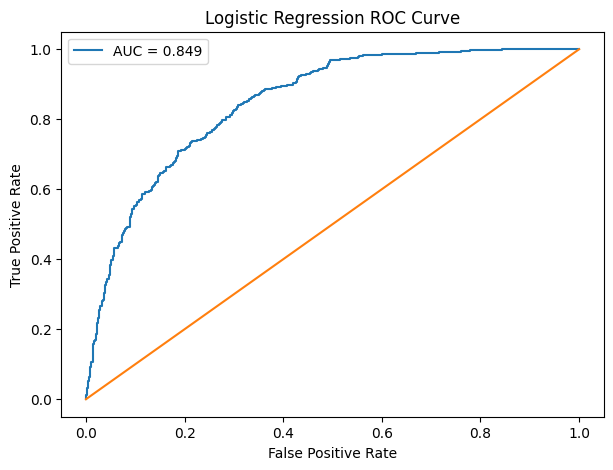

0.8493296132682322


In [ ]:
probs = model.predict_proba(
X_test
)[:,1]

fpr,tpr,_ = roc_curve(
y_test,
probs
)

roc_auc = auc(
fpr,
tpr
)

plt.figure(figsize=(7,5))

plt.plot(
fpr,
tpr,
label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
[0,1],
[0,1]
)

plt.xlabel(
"False Positive Rate"
)

plt.ylabel(
"True Positive Rate"
)

plt.title(
"Logistic Regression ROC Curve"
)

plt.legend()
plt.show()
print(roc_auc)

The Logistic Regression model achieved an ROC–AUC score of 0.849, indicating very good performance in distinguishing customers who are likely to churn from those who are likely to stay. This result shows that the model performs significantly better than random guessing and provides reliable support for customer churn prediction.

## Model 2 — Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)


In [ ]:
print(classification_report(
    y_test,
    pred_rf
))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.64      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409



Random Forest did not outperform Logistic Regression

The model achieved 79% accuracy and identified important factors such as Total Charges, Tenure Months, and Monthly Charges. Although Random Forest performed well, Logistic Regression provided better recall and stronger interpretability. Therefore, Logistic Regression was selected as the final model for this project.


## Why Predictive Modeling Was Performed

* After identifying patterns through exploratory data analysis, predictive modeling was performed to estimate whether a customer is likely to churn based on customer attributes and service usage. Since the target variable (Churn Value) contains two categories (0 = Stay, 1 = Churn), this became a classification problem.

* Logistic Regression was selected as the first model because it is simple, interpretable, and commonly used for binary classification problems. It helps understand which factors are associated with higher churn probability.

* Random Forest was selected because it is a powerful classification algorithm that works well with structured business data and can identify complex relationships between customer features. It was chosen to compare performance against Logistic Regression and check whether a more advanced model could improve churn prediction. Random Forest also provides feature importance, which helps explain business insights.


* Other algorithms were not used because the goal of this project was to build an accurate and understandable business solution rather than maximize complexity. Logistic Regression and Random Forest provided a good balance between performance and interpretability.


----------------------

#7. Feature Importance

## Feature Importance
* it identify which customer attributes has the greatest influence on churn prediction. Random Forest assigns importance scores to each feature based on how much it contributes to decision-making. Higher importance values indicate stronger influence on predicting whether a customer is likely to churn.


In [ ]:
importance=(
pd.Series(
    rf.feature_importances_,
    index=X.columns
)
.sort_values(ascending=False)
)
print(importance.head(10))

Total Charges                      0.158992
Tenure Months                      0.146733
Monthly Charges                    0.134460
CLTV                               0.124381
Internet Service_Fiber optic       0.041953
Payment Method_Electronic check    0.036743
Dependents_Yes                     0.035972
Contract_Two year                  0.029438
Gender_Male                        0.022681
Online Security_Yes                0.022478
dtype: float64



## Top contributing factors:

* Total Charges
* Tenure Months
* Monthly Charges
* CLTV
* Fiber Internet
* Electronic Check
* Contract Type
* Online Security

-----------------------

#8. Business Recommendations


* Convert month-to-month users into annual contracts.
* Focus retention campaigns during first 12 months.
* Promote Online Security and Tech Support bundles.
* Encourage automatic payment methods.
* Monitor high-paying Fiber customers

--------------------------------

# 10. Conclusion


## This project analyzed telecom customer churn using exploratory analysis, statistical validation, and predictive modeling.

Key findings revealed that:

* Contract duration strongly influenced churn.
* Customers with shorter tenure were more likely to leave.
* Higher monthly charges increased churn risk.
* Additional services such as Online Security and Tech Support improved retention.

Among evaluated models, Logistic Regression achieved the best balance between predictive performance and interpretability with an ROC-AUC score of 0.849.

The project demonstrates how data analytics can support customer retention strategies and improve business decision-making.

------------------------